In [ ]:
# from google.colab import drive
# drive.mount("/content/drive")

Mounted at /content/drive


In [1]:
import os
# import sys

In [ ]:
# GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = '' # Enter file path
# GOOGLE_DRIVE_PATH = os.path.join('drive', 'MyDrive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
# print(os.listdir(GOOGLE_DRIVE_PATH))

In [ ]:
# sys.path.append(GOOGLE_DRIVE_PATH)

In [42]:
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

torch.manual_seed(27)

%matplotlib inline

In [3]:
from models import MLP, Net
from preprocessing import SatelliteDataset
from training import train

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# df = pd.read_excel(os.path.join(GOOGLE_DRIVE_PATH, "train.xlsx"))
df = pd.read_excel("train.xlsx")

In [10]:
df[df.bedrooms > 15]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
3193,2402100895,20140625T000000,640000,33,1.75,1620,6000,1.0,0,0,...,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


In [11]:
df_clean = df[df.bedrooms < 15]

In [12]:
dataset = SatelliteDataset(df_clean)

/content/drive/MyDrive/Satellite Imagery Based Price Evaluation/satellite/preprocessing.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sqft_living = np.log(df.sqft_living.values)
/content/drive/MyDrive/Satellite Imagery Based Price Evaluation/satellite/preprocessing.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sqft_lot = np.log(df.sqft_lot.values)
/content/drive/MyDrive/Satellite Imagery Based Price Evaluation/satellite/preprocessing.py:41: SettingWithCopyWarning: 
A value is trying to b


Epoch 1:
Training loss: 151.10393743199785
Validation loss: 130.20278793231415

Epoch 2:
Training loss: 94.98997412152414
Validation loss: 59.893090403621734

Epoch 3:
Training loss: 34.34931173110229
Validation loss: 14.381774400306684

Epoch 4:
Training loss: 5.9362014799088625
Validation loss: 0.733758881286709

Epoch 5:
Training loss: 0.5110920979620445
Validation loss: 0.0689719417520249

Epoch 6:
Training loss: 0.1006394812691942
Validation loss: 0.08098664520062857

Epoch 7:
Training loss: 0.08604691199869666
Validation loss: 0.08014999454756369

Epoch 8:
Training loss: 0.07693246941883798
Validation loss: 0.12250045295509811

Epoch 9:
Training loss: 0.07063088269946122
Validation loss: 0.22345187657658466

Epoch 10:
Training loss: 0.0715815753545883
Validation loss: 0.04531807816619371

Epoch 11:
Training loss: 0.06354841766718886
Validation loss: 0.12004353630917812

Epoch 12:
Training loss: 0.06317164771826901
Validation loss: 0.3042321978786123

Epoch 13:
Training loss: 0.0

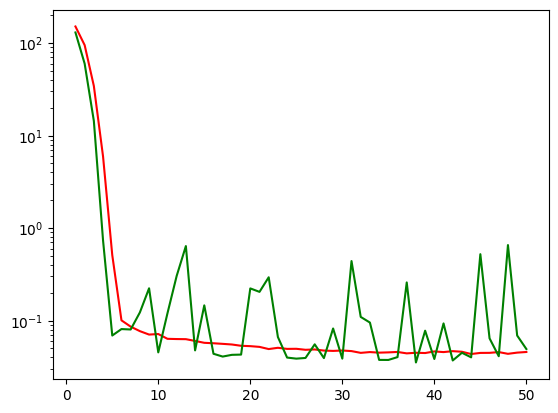

In [11]:
model = MLP(14, 8, 1, 70)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), weight_decay=1e-2)

train_loss, valid_loss = train(model, dataset, optimizer, split=0.7, batch_size=64, epochs=50, num_workers=2, device=device)

x = [i for i in range(1, len(train_loss)+1)]

plt.semilogy(x, train_loss, 'r', x, valid_loss, 'g')
plt.show()

In [ ]:
# torch.save(model.cpu().state_dict(), os.path.join(GOOGLE_DRIVE_PATH, "mlp"))
torch.save(model.cpu().state_dict(), "mlp")

In [ ]:
# model.load_state_dict(torch.load(os.path.join(GOOGLE_DRIVE_PATH, "mlp"), weights_only=True))
# model.load_state_dict(torch.load("mlp", weights_only=True))

<All keys matched successfully>

In [6]:
# df = pd.read_excel(os.path.join(GOOGLE_DRIVE_PATH, "train.xlsx"))
df = pd.read_excel("train.xlsx")

In [7]:
df_clean = df[df.bedrooms < 15]

In [10]:
# dataset = SatelliteDataset(df_clean, img=True, train_img_path=os.path.join(GOOGLE_DRIVE_PATH, "data"))
dataset = SatelliteDataset(df_clean, img=True, train_img_path="data")

c:\Users\devan\Desktop\usr\satellite\preprocessing.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sqft_living = np.log(df.sqft_living.values)
c:\Users\devan\Desktop\usr\satellite\preprocessing.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sqft_lot = np.log(df.sqft_lot.values)
c:\Users\devan\Desktop\usr\satellite\preprocessing.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c


Epoch 1:
Training loss: 128.10852862072704
Validation loss: 67.75192812355414

Epoch 2:
Training loss: 24.218787327544078
Validation loss: 1.607438807768903

Epoch 3:
Training loss: 0.5268217630247651
Validation loss: 0.2705536624077733

Epoch 4:
Training loss: 0.1651931167121709
Validation loss: 0.2343473118713994

Epoch 5:
Training loss: 0.12943267317898424
Validation loss: 0.20297702379048227

Epoch 6:
Training loss: 0.10239900416243491
Validation loss: 0.11488198366229876

Epoch 7:
Training loss: 0.09381205996735709
Validation loss: 0.10212495546146795

Epoch 8:
Training loss: 0.0804327228826907
Validation loss: 0.22703256828657964

Epoch 9:
Training loss: 0.07752502890293059
Validation loss: 0.08622484287557694

Epoch 10:
Training loss: 0.07184490121477445
Validation loss: 0.1037957887455389

Epoch 11:
Training loss: 0.0721795775597187
Validation loss: 0.11388082845500778

Epoch 12:
Training loss: 0.06374572406733493
Validation loss: 0.07165821305082189

Epoch 13:
Training loss: 

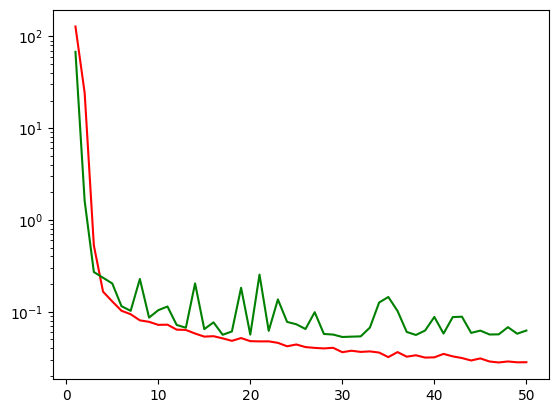

In [12]:
conv_model = Net(14, 80, 20, 1, 3, 70, 3)
conv_model = conv_model.to(device)

optimizer = torch.optim.Adam(conv_model.parameters(), weight_decay=1e-2)

train_loss, valid_loss = train(conv_model, dataset, optimizer, split=0.7, batch_size=64, epochs=50, num_workers=2, device=device, img=True)

x = [i for i in range(1, len(train_loss)+1)]

plt.semilogy(x, train_loss, 'r', x, valid_loss, 'g')
plt.show()

In [13]:
# torch.save(conv_model.cpu().state_dict(), os.path.join(GOOGLE_DRIVE_PATH, "mlp"))
torch.save(conv_model.cpu().state_dict(), "conv")

In [ ]:
# conv_model.load_state_dict(torch.load(os.path.join(GOOGLE_DRIVE_PATH, "conv"), weights_only=True))
# conv_model.load_state_dict(torch.load("conv", weights_only=True))

In [24]:
test = pd.read_excel("test.xlsx")
testset = SatelliteDataset(test, train=False, img=True, test_img_path="test")

pred_list = []

conv_model.eval()

with torch.inference_mode():

    for i in range(len(testset)):
        X, zip, img = testset[i]
        X = X.unsqueeze(0)
        zip = zip.unsqueeze(0)
        img = img.unsqueeze(0)
        pred = conv_model(X, zip, img)
        pred_list.append(pred.item())

In [35]:
pred = np.array(pred_list)
price_predict = np.exp(pred)
price_predict
df = pd.DataFrame({"id": testset.id, "price": price_predict})
df.head()

,id,price
0,2591820310,3.456483e+06
1,7974200820,1.233811e+07
2,7701450110,1.205660e+07
3,9522300010,2.964883e+07
4,9510861140,5.072297e+06


In [40]:
test = pd.read_excel("test.xlsx")
testset = SatelliteDataset(test, train=False)

pred_list = []

model.eval()

with torch.inference_mode():

    for i in range(len(testset)):
        X, zip = testset[i]
        X = X.unsqueeze(0)
        zip = zip.unsqueeze(0)
        img = img.unsqueeze(0)
        pred = model(X, zip)
        pred_list.append(pred.item())

In [53]:
pred = np.array(pred_list)
price_predict = np.exp(pred)
df = pd.DataFrame({"id": testset.id, "predicted_price": price_predict})
df.head()

,id,predicted_price
0,2591820310,3.363005e+05
1,7974200820,7.273623e+05
2,7701450110,9.379934e+05
3,9522300010,1.449090e+06
4,9510861140,7.146488e+05


In [54]:
df.to_excel("predictions.xlsx")